In [8]:
import polars as pl
from pathlib import Path

ROOT = Path.cwd()
OUT_DIR = ROOT / "data" / "output"
if not OUT_DIR.exists():
    OUT_DIR = ROOT.parent / "data" / "output"

parquet_path = OUT_DIR / "forecast_seccion_1_partial.parquet"
if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

df = pl.read_parquet(parquet_path)

shape: (5, 3)
┌────────────┬───────────┬──────────┐
│ ds         ┆ value     ┆ valuehat │
│ ---        ┆ ---       ┆ ---      │
│ date       ┆ f64       ┆ f64      │
╞════════════╪═══════════╪══════════╡
│ 2024-05-26 ┆ 2134653.8 ┆ 2.0427e6 │
│ 2024-05-27 ┆ 1.9304e6  ┆ 2.0117e6 │
│ 2024-05-28 ┆ 2.0906e6  ┆ 2.2787e6 │
│ 2024-05-29 ┆ 1.8514e6  ┆ 1.9099e6 │
│ 2024-05-30 ┆ 1.7116e6  ┆ 1.8177e6 │
└────────────┴───────────┴──────────┘


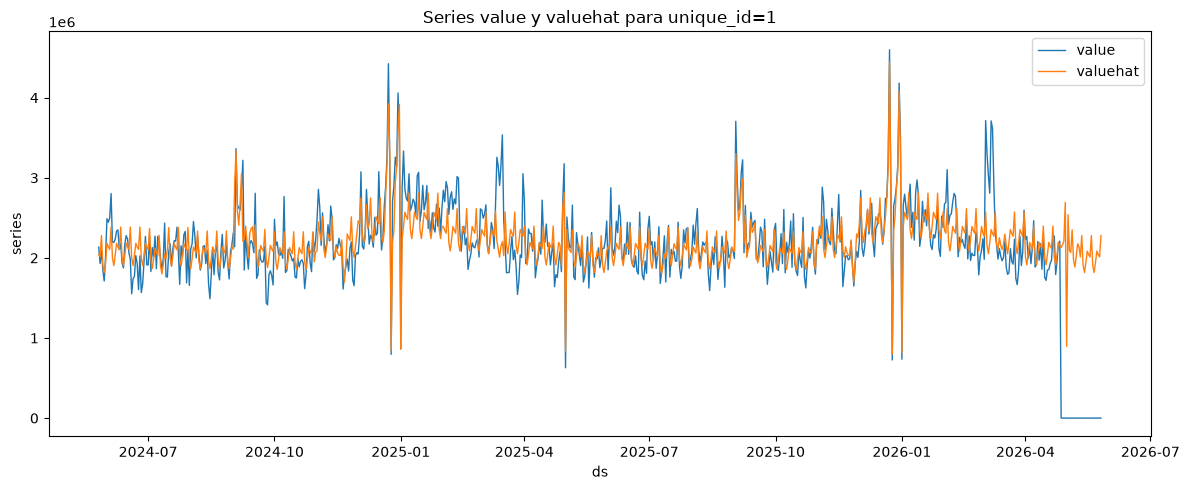

In [9]:
import matplotlib.pyplot as plt


def graph_plot(filtered: pl.DataFrame):
    x = filtered["ds"].to_list()
    y_value = filtered["value"].to_list()
    y_valuehat = filtered["valuehat"].to_list()

    plt.figure(figsize=(12, 5))
    plt.plot(x, y_value, label="value", linewidth=1)
    plt.plot(x, y_valuehat, label="valuehat", linewidth=1)
    plt.xlabel("ds")
    plt.ylabel("series")
    plt.title("Series value y valuehat para unique_id=1")
    plt.legend()
    plt.tight_layout()
    plt.show()


filtered = (
    df.filter(pl.col("unique_id") == "1").select(["ds", "value", "valuehat"]).sort("ds")
)

print(filtered.head())

graph_plot(filtered)

In [10]:
# Mostrar cantidad de filas por cada unique_id
counts = (
    df.group_by("unique_id")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
)
print(counts.head(10))

shape: (9, 2)
┌────────────┬────────┐
│ unique_id  ┆ n_rows │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ 1||T:00003 ┆ 731    │
│ 1||T:00211 ┆ 731    │
│ 1||T:00025 ┆ 731    │
│ 1||T:00154 ┆ 731    │
│ 1          ┆ 731    │
│ 1||T:00001 ┆ 731    │
│ 1||T:00411 ┆ 731    │
│ 1||T:00063 ┆ 731    │
│ 1||T:00122 ┆ 731    │
└────────────┴────────┘


In [11]:
wmape_path = OUT_DIR / "wmape.parquet"

df_wmape = pl.read_parquet(wmape_path)
df_wmape.filter(
    (pl.col("wmape") != 0) & pl.col("unique_id").str.starts_with("1||")
).sort("wmape", descending=False)

unique_id,wmape,bias,n_points,sum_y,sum_yhat
str,f64,f64,u32,f64,f64
"""1||T:00063""",0.083668,0.016812,697,800781.19,814244.0
"""1||T:00154""",0.098415,0.005643,701,730822.64,734947.0
"""1||T:00003""",0.106847,-0.013662,696,1.3452e6,1.326833e6
"""1||T:00211""",0.118452,0.005795,696,764901.71,769334.0
"""1||T:00001""",0.121164,0.001234,698,5.8271e6,5.834338e6
"""1||T:00122""",0.137613,0.004854,701,823779.76,827778.0
"""1||T:00411""",0.160345,-0.036954,701,1.4111e6,1.358979e6
"""1||T:00025""",0.259798,-0.092443,701,694157.92,629988.0


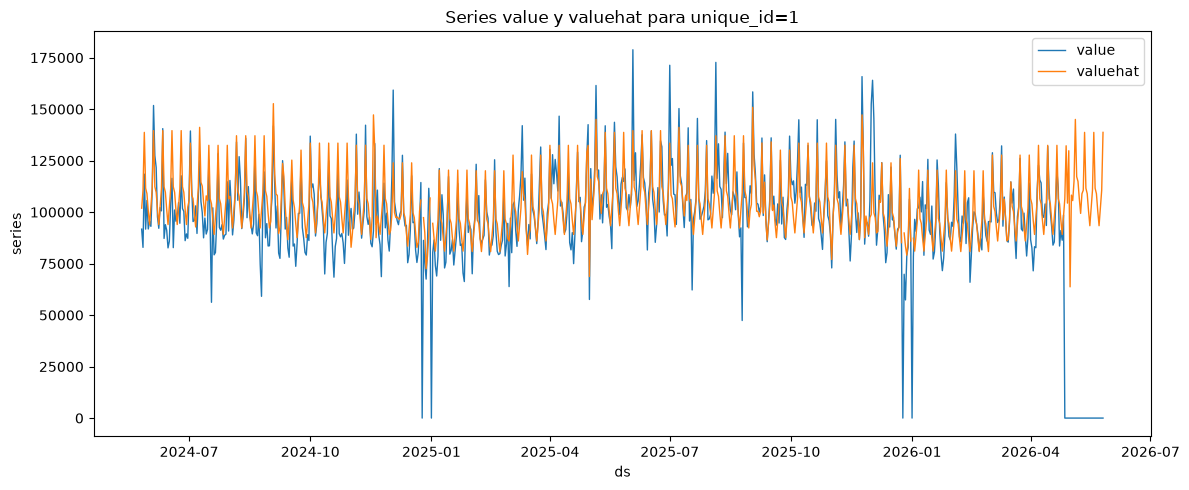

In [12]:
filtered = (
    df.filter(pl.col("unique_id") == "1||T:00063")
    .select(["ds", "value", "valuehat"])
    .sort("ds")
)

graph_plot(filtered)

In [ ]:
df.filter(
    (pl.col("unique_id") == "1||T:00063") & (pl.col("period_type") == "forecast_only")
).sort("ds")